## Day 20

**step: 1**
- Import libraries

In [1]:
import pandas as pd

**step: 2**
- Load the dataset
- understand data.

In [2]:
df = pd.read_csv("winequality_red.csv")
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [4]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


**step: 3**
- check missing values

In [5]:
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

- No missing values found

**step: 4**

- Understanding behavior before prediction

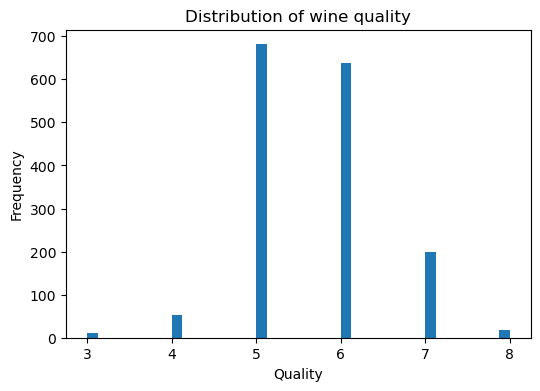

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.hist(df["quality"], bins=40)
plt.title("Distribution of wine quality")
plt.xlabel("Quality")
plt.ylabel("Frequency")
plt.show()

- The target variable is moderately imbalanced, so accuracy alone is not a reliable metric.
- Most wines are rated 5 or 6.
- Very few wines at extremes (3, 4, 8).

**Boxplot**

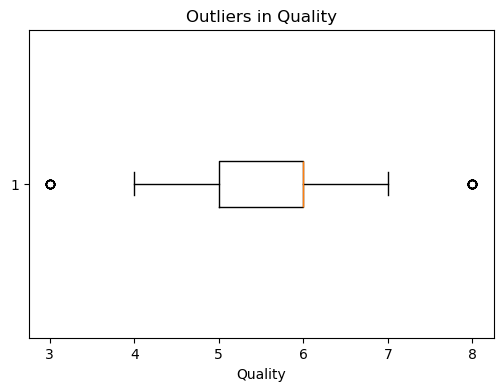

In [13]:
plt.figure(figsize=(6,4))
plt.boxplot(df["quality"], vert=False)
plt.title("Outliers in Quality")
plt.xlabel("Quality")
plt.show()

In [ ]:
- No outliers found.

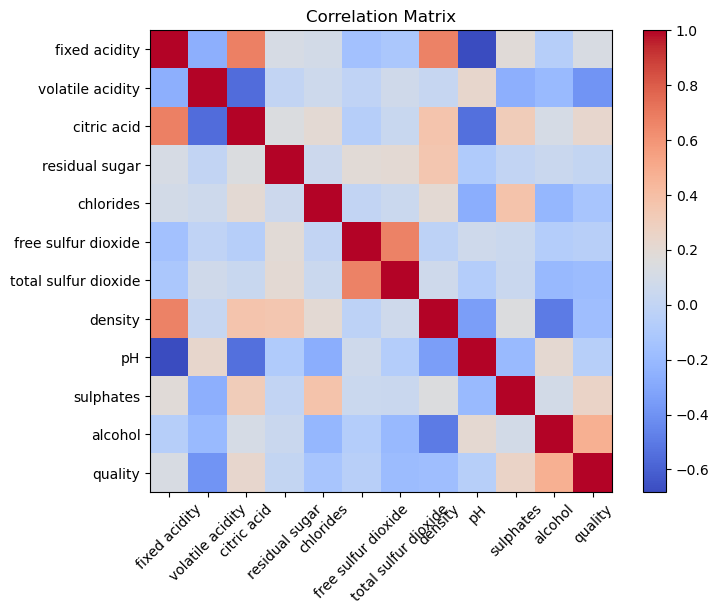

In [14]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns

corr = df[numeric_cols].corr()

plt.figure(figsize=(8,6))
plt.imshow(corr, cmap="coolwarm")
plt.colorbar()
plt.xticks(range(len(corr)), corr.columns, rotation=45)
plt.yticks(range(len(corr)), corr.columns)
plt.title("Correlation Matrix")
plt.show()

- Alcohol ↑ → Quality ↑ (strong positive correlation)
- Sulphates ↑ → Quality ↑
- Volatile acidity ↑ → Quality ↓ (negative correlation)
- Alcohol and sulphates show strong positive correlation with quality, while volatile acidity     has a negative impact.

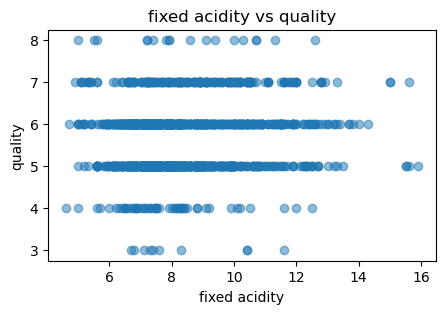

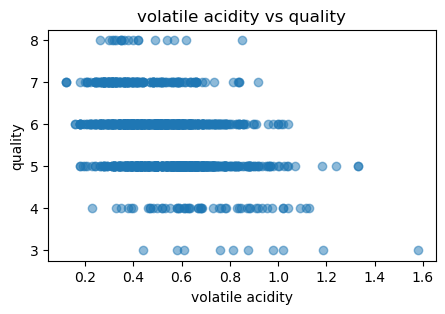

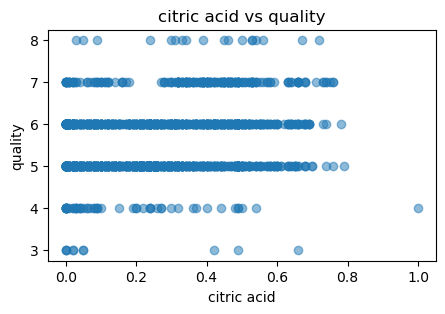

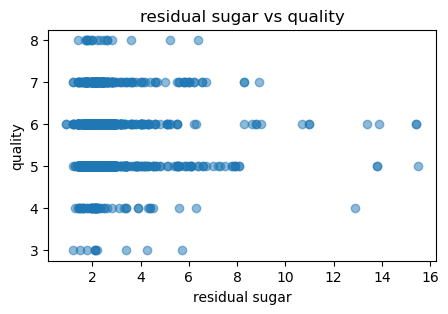

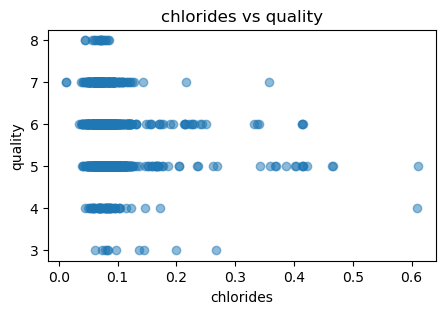

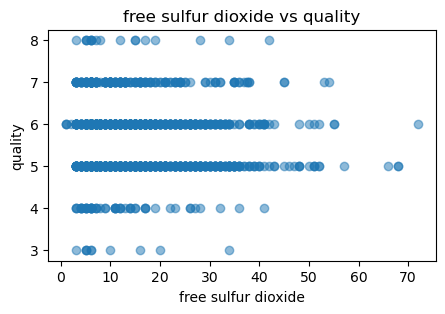

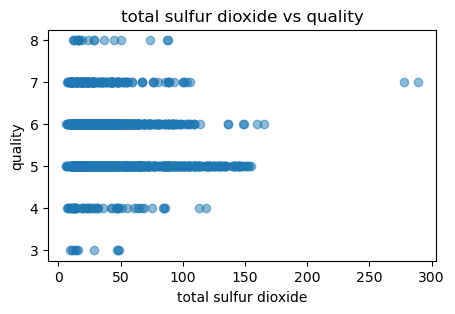

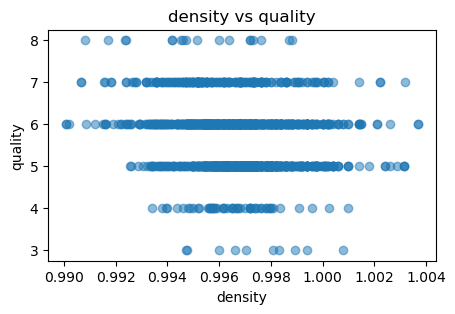

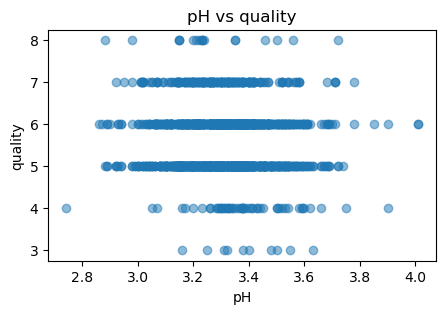

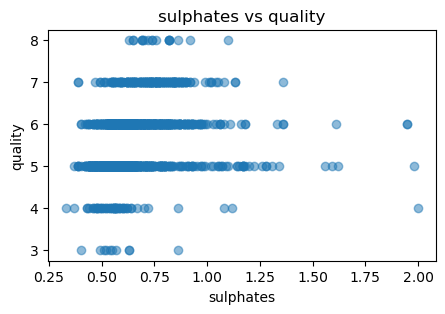

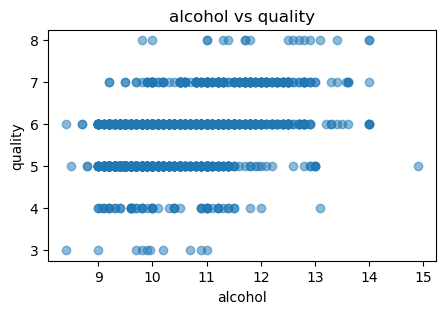

In [17]:
for col in numeric_cols:
    if col != "quality":
        plt.figure(figsize=(5,3))
        plt.scatter(df[col], df["quality"], alpha=0.5)
        plt.xlabel(col)
        plt.ylabel("quality")
        plt.title(f"{col} vs quality")
        plt.show()

**Fixed Acidity vs Quality**
- Points are scattered.
- No clean upward/downward trend.
- Fixed acidity alone is not predictive.
- Might still help in combination with other features.
    
**Volatile Acidity vs Quality (Scatter)**
- As volatile acidity increases → quality generally decreases.
- High volatile acidity = vinegar-like taste = bad wine.

**Residual Sugar vs Quality**
- Most wines have low residual sugar.
- Quality doesn’t increase much with sugar.

**Free Sulfur Dioxide vs Quality**
- High scatter.
- No strong pattern.

**Total Sulfur Dioxide vs Quality**
- Very high values → generally lower quality.
- Too much sulfur = harsh taste.